In [689]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import satkit as sk
import geopandas as gpd
from datetime import datetime as dt
from time import strftime, localtime

In [690]:
PATH = "data/"

In [691]:
### IMPORTING DATA ###
tdrs_df = pd.read_excel(PATH + "tdrs5j.xls")
goes16_df = pd.read_excel(PATH + "g16_g17_exs_spw.xlsx", sheet_name= "g16_exs_spw")
goes17_df = pd.read_excel(PATH + "g16_g17_exs_spw.xlsx", sheet_name= "g17_exs_spw")
anom_df = pd.read_excel(PATH + "anom5j.xls")
flp_df = pd.read_csv(PATH + "flp/flp_seu.csv")
anom_df = anom_df[anom_df["ADIAG"] == "SEU"] # Filter for only SEU
print(anom_df["BIRD"].unique())

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
<StringArray>
[ 'AUSSAT-A1',  'AUSSAT-A2',  'AUSSAT-A3',       'ERBS',      'GMS-2',
      'GMS-3',     'GOES-4',     'GOES-5',     'GOES-6',     'GOES-7',
   'INSAT-1B',   'INSAT-1C',      '@GG0K',    '@GG0401',    '@GG0402',
    '@GG0403',    '@GG0404',    '@GG0405',    '@GG0407',    '@GG0408',
    '@GG0411',    '@GG0412',    '@GG0416',    '@GG0501',    '@GG0502',
    '@GG0503',    '@GG0504',    '@GG0505',    '@GG0506',    '@GG0507',
    '@GG0508',   'INTEL603', 'PIONEER-12',  'SBS1[F-3]',  'SBS2[F-1]',
  'SBS3[F-2]',  'SBS4[F-4]',     'STS-37',     'STS-39',     'STS-43',
     'STS-44',     'STS-48',     'TDRS-4',     'TDRS-5',      'TOPEX']
Length: 45, dtype: str


# ANOM5J/TDRS5J HEADINGS:
* BIRD  = Spacecraft identification
* ADATE = Date of anomaly (CCYYMMDD Universal Time)
* ADIAG = anomaly type
* NS    = North/South latitude
* LAT   = Geographic latitude of sub-orbit point at anomaly start
* EW    = East/West longitude 
* LON   = Geographic longitude of sub-orbit point at anomaly start

In [692]:
'''
- This cell is for reformatting the GOES-16/17 data to fit into the tdrsj5 and anomj5 database. 
- The GOES database only has timestamps for SEU but no location data. Possible solution is pulling TLEs computing orbit and inserting here. 
    - Tutorial https://www.youtube.com/watch?v=NQTtFrhSNDk, https://satellite-toolkit.readthedocs.io/v0.5.4/examples/Two-Line%20Element%20Set.html
- The timestamp of GOES data offers two formats
    1. UTC
    2. yyyy-mm-dd hh-mm-ss
reformating (2) to mm/dd/yyyy to match tdrsj5 and anomj5 ADATE
'''

master_data = [tdrs_df, anom_df] # list of dataframes that follow column name convention and data format. TDRS and anom files have same file format

goes_16_17_data = [goes16_df, goes17_df] 
goes_names = ["GOES-16", "GOES-17"] # no BIRD field in GOES data

goes_tles = {"GOES-16": ["0 GOES-16",
                        "1 41866U 16071A   26105.56417821 -.00000085  00000+0  00000+0 0  9990",
                        "2 41866   0.1837  84.9523 0001634 245.3112 331.8722  1.00271214 34471"],
            "GOES-17": ["0 GOES-17",
                        "1 43226U 18022A   26105.56712488 -.00000176  00000+0  00000+0 0  9998",
                        "2 43226   0.7761  86.5840 0000850 265.2464 326.5778  1.00271495 29797"]} # https://celestrak.org/norad/elements/table.php?GROUP=goes&FORMAT=2le

goes_df = pd.DataFrame()

for i in range(len(goes_16_17_data)): # for each goes satellite data
    goes_data = goes_16_17_data[i] 

    goes_datetime_col = [] # new list of datetimes 
    goes_ns_col = []
    goes_ew_col = []
    goes_lat_col = []
    goes_lon_col = []
    goes_alt_col = []

    for index, row in goes_data.iterrows(): # pull the old datetime

        datetime = row["Datetime"]
                                  
        goes_adate_year = str(datetime.year) # separate datetime components  
        goes_adate_month = str(datetime.month)
        goes_adate_day = str(datetime.day)
        goes_adate_hour = int(datetime.hour)
        goes_adate_minute = int(datetime.minute)
        goes_adate_second = int(datetime.second)

    
        goes_tle_object = sk.TLE.from_lines(goes_tles[goes_names[i]])
        tle_time = sk.time(int(goes_adate_year), int(goes_adate_month), int(goes_adate_day), goes_adate_hour, goes_adate_minute, goes_adate_second)
        pTEME, _vTEME = sk.sgp4(goes_tle_object, tle_time)
        pITRF = sk.frametransform.qteme2itrf(tle_time) * pTEME
        goes_lla = sk.itrfcoord(pITRF)

        if goes_lla.latitude_deg < 0: # Pulling Lat/Long/Alt position lla using this method https://satellite-toolkit.readthedocs.io/v0.5.4/examples/Two-Line%20Element%20Set.html
            goes_ns_col.append("S")
            goes_lat_col.append(abs(goes_lla.latitude_deg))
        else:
            goes_ns_col.append("N")
            goes_lat_col.append(goes_lla.latitude_deg)
        
        if goes_lla.longitude_deg < 0:
            goes_ew_col.append("W")
            goes_lon_col.append(abs(goes_lla.longitude_deg))
        else:
            goes_lon_col.append(goes_lla.longitude_deg)

        goes_alt_col.append(goes_lla.altitude * 1000) # km -> m

        newdate = goes_adate_month + "/" + goes_adate_day + "/" +goes_adate_year # reformat into new datetime 
        newdate = pd.to_datetime(newdate)
        goes_datetime_col.append(newdate) # add to list of new datetime

    goes_name_col = [] # list of goes sat name based on number of entries

    for j in range(goes_data.shape[0]):
        goes_name_col.append(goes_names[i])

    goes_map = {"BIRD": goes_name_col, # name
                 "ADATE": goes_datetime_col, #seu date
                   "NS": goes_ns_col, # North or south
                     "LAT": goes_lat_col, #latitude
                       "EW": goes_ew_col, # east or west
                         "LON": goes_lon_col, #longitude
                           "ALT": goes_alt_col} # altitude
    new_goes_data = pd.DataFrame(goes_map) # convert to dataframe
    master_data.append(new_goes_data) # add to master data list




In [693]:
flp_datetime_col = []
flp_lat_col      = []
flp_ns_col       = []
flp_lon_col      = []
flp_ew_col       = []
flp_alt_col      = []
flp_name_col     = []
for index, row in flp_df.iterrows():
    flp_adate = pd.to_datetime(row["Time"]) 
    flp_datetime_col.append(flp_adate)
    flp_name_col.append('FLP')

    # flp_adate_year = str(flp_adate.year)
    # flp_adate_month = str(flp_adate.month)
    # flp_adate_day = str(flp_adate.day)

    # flp_newdate = flp_adate_month + "/" + flp_adate_day + "/" + flp_adate_year
    # flp_newdate = pd.to_datetime(flp_newdate)

    # flp_datetime_col.append(flp_newdate)
    flp_lat = row['Lat (deg)'] 
    flp_lon = row["Lon (deg)"]
    flp_alt = row['Alt (m)']
    if flp_lat < 0: 
        flp_ns_col.append("S")
        flp_lat_col.append(abs(flp_lat))
    else:
        flp_ns_col.append("N")
        flp_lat_col.append(flp_lat)
    
    if flp_lon < 0:
        flp_ew_col.append("W")
        flp_lon_col.append(abs(flp_lon))
    else:
        flp_ew_col.append("E")
        flp_lon_col.append(flp_lon)
    flp_alt_col.append(flp_alt)

    flp_map = {"BIRD": flp_name_col,
               "ADATE": flp_datetime_col,
               "NS": flp_ns_col,
               "LAT": flp_lat_col,
               "EW": flp_ew_col,
               "LON": flp_lon_col,
               "ALT": flp_alt_col}


new_flp_data = pd.DataFrame(flp_map)
master_data.append(new_flp_data)

In [694]:
seu_df = pd.concat(master_data) # merge all dataframes into one
print(f"The number of SEUs over all satellite data collected: {seu_df.shape[0]}")

The number of SEUs over all satellite data collected: 10535


In [695]:
seu_timedate_count = seu_df.groupby("ADATE")["BIRD"].count() #date with number of SEU reported for that day

seu_days = seu_timedate_count.index # day of SEUs
seu_days = seu_days.to_numpy()

seu_days = np.unique(seu_days) # unique days (shouldnt matter really), trying to handle SEUS that are counted on the same day but at multiple times during the day, however all dates are now in format yyyy/mm/dd

seu_count_per_day = []
for i in range(len(seu_days)):
    seu_count_per_day.append(seu_timedate_count[seu_days[i]]) # give me the count of SEUs per day in a list

In [696]:
solar_cycles = {"sc21": (pd.Timestamp('1976-03-01'), pd.Timestamp('1979-12-01')),
                "sc22": (pd.Timestamp('1986-09-01'), pd.Timestamp('1989-11-01')),
                "sc23": (pd.Timestamp('1996-08-01'), pd.Timestamp('2001-11-01')),
                "sc24": (pd.Timestamp('2008-12-01'), pd.Timestamp('2014-04-01'))} # solar-cycle##: (solar-min_date , solar-max_date) wikepedia

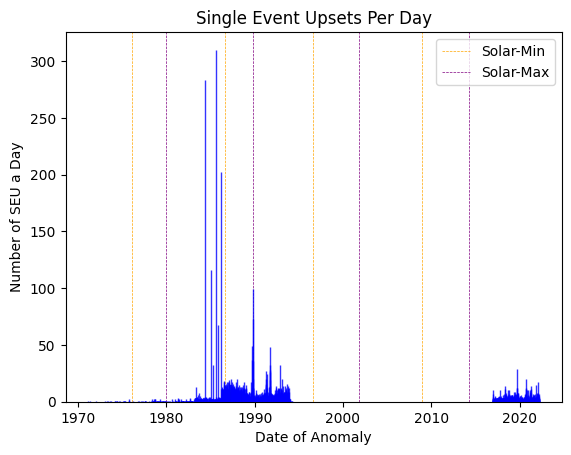

In [697]:
### plotting SEUs timestamps with solar cycle. We should expect to see an uptick in SEUs during solar min and decrease during solar max Lohmeyer 2013
fig, ax = plt.subplots()

solar_cycles_list = list(solar_cycles)

for i in range(len(solar_cycles_list)):
    solar_min = solar_cycles[solar_cycles_list[i]][0]
    solar_max = solar_cycles[solar_cycles_list[i]][1]
   
    ax.axvline(x = solar_min, linestyle = "--", linewidth = .5, color = 'orange', label = 'Solar-Min' if i == 0 else "")
    ax.axvline(x = solar_max, linestyle = '--', linewidth = .5, color = 'purple', label = 'Solar-Max' if i == 0 else "")

ax.bar(seu_days, seu_count_per_day,
       width=0.5,
       edgecolor='blue',
       alpha=0.8,
       zorder=3)

ax.legend()
ax.set_title("Single Event Upsets Per Day")
ax.set_ylabel("Number of SEU a Day")
ax.set_xlabel("Date of Anomaly")
ax.set_ylim(0, np.max(seu_count_per_day) * 1.05)

plt.show()

In [698]:
abs_long = []
abs_lat = []
for index, row in seu_df.iterrows():
    if row["NS"] == "S":
        abs_lat.append(- row["LAT"])
    else:
        abs_lat.append(row["LAT"])
    
    if row["EW"] == "E":
        abs_long.append( row["LON"])
    else:
        abs_long.append(-row["LON"])
print(len(abs_long), len(abs_lat))
abs_long = [(lon + 180) % 360 - 180 for lon in abs_long]


10535 10535


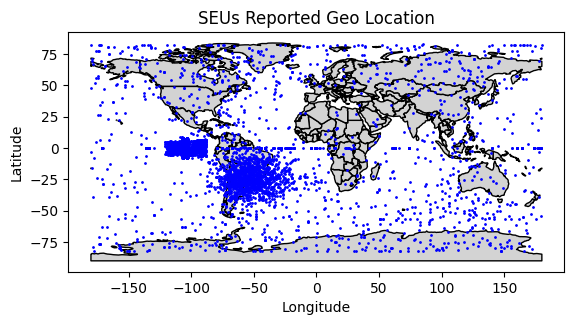

In [699]:
#Plotting lla of SEUs on surface map

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

fig, ax = plt.subplots()

# Plot map
world.plot(ax=ax, color='lightgray', edgecolor='black')

ax.scatter(abs_long, abs_lat, s=1, c = 'b')

ax.set_title("SEUs Reported Geo Location")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()